10 · Centrality, and getting the answer back out

The last of the five-notebook OSMnx suite. Notebook 06 got a street network
into Blender, 11 measured its edges, 12 routed over it, 13 asked what it
reaches. This one asks which streets the network makes important, and how to
get that answer out.

1. `osmnx_centrality` is not `calculate_centrality`: different sources,
   different treatment of direction, different destinations. The OSMnx one
   offers the **line graph**, so betweenness is a property of *streets*
   rather than of intersections.
2. Whether it honors edge weights. The generic operators cannot: `GraphData`
   has no weights field (`core/algorithms/graph.py:3`, notebook 03). The
   OSMnx one has its own code path and a `Use Length Weight` checkbox, and
   section 2's answer is not the one that checkbox implies.
3. What survives each of the eight export routes. Half carry the numbers,
   and none says which.

Study area: Ciutat Vella, València (39.4699, -0.3763), 600 m, `drive`, the
same disc as notebook 06, so the Overpass response is already cached.
Betweenness costs `O(nm)` shortest paths: 243 intersections is sized for the
*analysis*, not for the picture.

## 0 · Setup

In [1]:
import importlib
import json
import os
import pathlib
import sys
import tempfile
import time


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import networkx as nx
import numpy as np

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

### The cache goes first, as always

`nb.osmnx()` sets `ox.settings.cache_folder` and `use_cache`;
notebook 06 covers why the second matters to a shared Overpass endpoint. It
has to run **before the first operator**, because the importer imports the
same `osmnx` module object this notebook does.

In [2]:
ox = nb.osmnx()
print(f"osmnx        {ox.__version__}")
print(f"cache_folder {nb.rel(ox.settings.cache_folder)}")

osmnx        2.0.7
cache_folder notebooks/data/cache/osmnx


### The installed add-on, and why the modules come from there

The operators run inside the copy of SciGraphs that **Blender registered**,
and the graph they leave behind lives in a module-level dict inside *that*
copy. `import SciGraphs` reaches a different module object with an
empty cache, and every `get_osmnx_graph` would come back `None`. So the four
modules below are fetched from the installed package by name, as in 10 to 13.

In [3]:
CENTER = (39.4699, -0.3763)      # Ciutat Vella, València
RADIUS_M = 600

INSTALLED = next(k for k in bpy.context.preferences.addons.keys()
                 if k.rsplit(".", 1)[-1].lower() == "scigraphs")
graph_cache = importlib.import_module(INSTALLED + ".core.osmnx.graph_cache")
# `scigraphs_core` is a wheel: one copy in site-packages, shared by the notebook
# and the operators, so the installed/working-tree split does not apply to it.
mesh_bridge = importlib.import_module("scigraphs_core.osmnx.mesh_bridge")
sg_centrality = importlib.import_module("scigraphs_core.osmnx.centrality")
sg_mesh_utils = importlib.import_module("scigraphs_core.mesh.mesh_utils")

print("add-on package:", INSTALLED)

add-on package: bl_ext.user_default.scigraphs


### Two helpers

`download(...)` writes every OSMnx scene property before firing
`scigraphs.import_osm_graph`. The operator reads *all* of them off
`scene.scigraphs`, so a property left set by an earlier cell is the easiest
way to get a graph you did not ask for; this resets the lot.

`node_attribute(...)` puts a per-node quantity on the mesh so a figure can be
colored by it. `mesh_bridge.transfer_node_attribute_to_mesh` does the first
half (section 4 uses it) but leaves every *street-shape* vertex at `0.0`, and
an OSMnx import at `retain_geometry=True` is mostly street-shape vertices.
Here each takes the mean of the two intersections its street runs between.
That changes the attribute's floor, not the picture: a `POINT` attribute
colors the node spheres and the tubes stay neutral, as figure 1 shows.

In [4]:
def download(network_type='drive', simplify=True, distance=RADIUS_M):
    """Set every OSMnx scene property, then run `scigraphs.import_osm_graph`."""
    props = bpy.context.scene.scigraphs
    props.osmnx_download_method = 'POINT'
    props.osmnx_network_type = network_type
    props.osmnx_simplify = bool(simplify)
    props.osmnx_retain_all = False
    props.osmnx_truncate_by_edge = True
    props.osmnx_retain_geometry = True
    props.osmnx_custom_filter_preset = 'NONE'
    props.osmnx_custom_filter_text = ""
    props.osmnx_which_result = 0
    props.osmnx_scale = 0.001
    props.osmnx_place_name = ""
    props.osmnx_address = ""
    props.osmnx_latitude, props.osmnx_longitude = CENTER
    props.osmnx_distance = int(distance)

    started = time.time()
    try:
        result = bpy.ops.scigraphs.import_osm_graph()
    except RuntimeError as exc:          # the operator reports and cancels
        print(f"  import_osm_graph failed: {exc}")
        return None
    if 'FINISHED' not in result:
        return None
    obj = bpy.context.active_object
    obj["download_seconds"] = round(time.time() - started, 2)
    return obj


def node_attribute(obj, values, name):
    """Write a per-node quantity onto the mesh, filling the street geometry.

    `values` maps node id -> number. Returns (intersections written, array).
    """
    mesh = obj.data
    ids = str(obj.get("nodes_data", "")).split(",")
    array = np.zeros(len(mesh.vertices), dtype=np.float64)
    filled = np.zeros(len(mesh.vertices), dtype=bool)

    def key(text):
        return int(text) if text.lstrip("-").isdigit() else text

    for index, node_id in enumerate(ids):
        if index >= len(array):
            break
        value = values.get(key(node_id))
        if value is not None:
            array[index] = float(value)
            filled[index] = True

    edge_verts = np.empty(len(mesh.edges) * 2, dtype=np.int32)
    mesh.edges.foreach_get("vertices", edge_verts)
    edge_verts = edge_verts.reshape(-1, 2)
    for (u, v), indices in mesh_bridge.build_edge_mapping(obj).items():
        a, b = values.get(key(u)), values.get(key(v))
        if a is None or b is None:
            continue
        middle = 0.5 * (float(a) + float(b))
        for edge_index in indices:
            for vertex in edge_verts[edge_index]:
                if not filled[vertex]:
                    array[vertex] = middle

    if name in mesh.attributes:
        mesh.attributes.remove(mesh.attributes[name])
    layer = mesh.attributes.new(name=name, type='FLOAT', domain='POINT')
    layer.data.foreach_set("value", array.astype(np.float32).tolist())
    return int(filled.sum()), array


sg.graphs.clear_scene(keep_anchor=False)
props = bpy.context.scene.scigraphs
print("scene cleared")

scene cleared


### The network

In [5]:
net = download('drive')
net.name = "Streets_drive"
G = graph_cache.get_osmnx_graph(net)

print(f"{G.number_of_nodes()} intersections, {G.number_of_edges()} directed "
      f"street segments, {type(G).__name__}")
print(f"mesh: {len(net.data.vertices)} vertices, {len(net.data.edges)} edges")
print(f"downloaded in {net['download_seconds']} s")

check("the network is in the scene and carries a graph",
      bool(net.get("is_osmnx")) and G.number_of_nodes() > 100)


  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 0.27s
Total import time: 0.30s
  Nodes: 243, Edges: 375

Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_drive.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_drive.graphml
Info: Imported: 243 intersections, 375 street segments, 31.8 km total
243 intersections, 375 directed street segments, MultiDiGraph
mesh: 1374 vertices, 1492 edges
downloaded in 0.33 s
[PASS] the network is in the scene and carries a graph


True

### Checking that this is the graph that was asked for

Two reasons from notebook 06, both able to hand you a different network
without an error.

The GraphML cache filename does not identify the graph. It is built from the
coordinates and network type alone (`core/osmnx/cache.py:78-105`, written at
`data_operators.py:659` and `:661`), so the radius, `simplify`,
`retain_all` and any custom filter are absent from the key: six different
downloads in notebook 06 all wrote to `39.4699_-0.3763_drive.graphml`. A
fallback read can return a 600 m graph where 300 m was asked for, and
centrality on the wrong graph still looks like an answer.

The cleaning operators replace the cached graph and never rebuild the mesh:
`osmnx_simplify`, `osmnx_consolidate`, `osmnx_to_undirected`,
`osmnx_to_digraph`, `osmnx_largest_component` and all three truncations
(`graph_operators.py:477-480, 518-521, 575-578, 663-666, 707-710, 754-757`).
A centrality written onto the stale mesh lands on the wrong vertices, and
anything exported afterwards exports the old graph. This notebook calls none
of them.

The comparison is against OSMnx called directly with the *float32* center the
operator really used (notebook 06 §1: the number you type is not the number
that goes over the wire).

In [6]:
queried = (props.osmnx_latitude, props.osmnx_longitude)
direct = ox.graph_from_point(queried, dist=RADIUS_M, network_type='drive',
                             simplify=True, truncate_by_edge=True)

print(f"asked for        {queried[0]!r}, {queried[1]!r}, {RADIUS_M} m, drive")
print(f"OSMnx directly   {direct.number_of_nodes()} nodes, "
      f"{direct.number_of_edges()} edges")
print(f"in the scene     {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"simplified flag  {G.graph.get('simplified')!r}")
print(f"mesh says        num_nodes={net['num_nodes']}, num_edges={net['num_edges']}")

check("the graph in the scene is the one that was requested",
      set(direct.nodes) == set(G.nodes)
      and direct.number_of_edges() == G.number_of_edges(),
      "not a stale cache entry from another radius")
check("it is simplified, as asked", bool(G.graph.get("simplified")))
check("the mesh and the graph agree on how big the network is",
      int(net["num_nodes"]) == G.number_of_nodes()
      and int(net["num_edges"]) == G.number_of_edges(),
      "no cleaning operator has run between the import and here")

asked for        39.46989822387695, -0.37630000710487366, 600 m, drive
OSMnx directly   243 nodes, 375 edges
in the scene     243 nodes, 375 edges
simplified flag  True
mesh says        num_nodes=243, num_edges=375
[PASS] the graph in the scene is the one that was requested — not a stale cache entry from another radius
[PASS] it is simplified, as asked
[PASS] the mesh and the graph agree on how big the network is — no cleaning operator has run between the import and here


True

### And that `length` is in meters

Sections 2 to 5 all weight by `length`. `osmnx_add_edge_lengths` computes
great-circle distances from whatever coordinates the graph is carrying and
never checks the CRS (`core/osmnx/edge_attributes.py:29-56`), so run on an
**unprojected** graph it writes degrees into a field called `length`: mean
0.00087 where 84.75 was meant, a factor of about 97 000, and nothing raises.

This notebook never calls it; the lengths come from the download, where OSMnx
computes them itself. The check is here anyway, because "I did not call the
broken thing" is not evidence.

In [7]:
lengths = np.array([float(d.get("length", 0.0))
                   for *_ids, d in G.edges(data=True)])
print(f"edge length: min {lengths.min():.1f}  median {np.median(lengths):.1f}  "
      f"mean {lengths.mean():.1f}  max {lengths.max():.1f}")
print(f"total street length {lengths.sum() / 1000:.1f} km over a "
      f"{2 * RADIUS_M} m disc")

check("`length` is in meters, not degrees",
      5.0 < np.median(lengths) < 500.0,
      "a city block is tens of meters; degrees would put the median "
      "near 0.0009")

edge length: min 1.3  median 75.0  mean 84.8  max 587.6
total street length 31.8 km over a 1200 m disc
[PASS] `length` is in meters, not degrees — a city block is tens of meters; degrees would put the median near 0.0009


True

## 1 · Two centrality operators, and they are not the same function

Both put a float on every node and nothing in either panel says they will
disagree. They do.

| | `calculate_centrality` | `osmnx_centrality` |
|---|---|---|
| Reads | the **mesh**: `nodes_data`/`edges_data` through `parse_graph_data_filtered` | the **in-memory `MultiDiGraph`** through `get_osmnx_graph` |
| Direction | symmetrized: builds an undirected graph (notebook 03 §5) | the directed multigraph, one-ways and all |
| Parallel edges | collapsed by the mesh | kept by NetworkX, collapsed by the fast path (§2) |
| Methods | degree, betweenness, closeness, eigenvector, PageRank | betweenness (node), betweenness (**edge**), closeness |
| Weights | none: `GraphData` has no field for them | a `length` checkbox, whose behavior is §2 |
| Writes | `centrality_<method>` on `POINT` | `betweenness` / `closeness` on `POINT`, `edge_betweenness` on `EDGE` |
| Backend | pure NetworkX | **rustworkx** when available, NetworkX otherwise |

The row that decides which one you want is **methods**, not for the count:
`osmnx_centrality` offers *edge* betweenness on the line graph, which is what
street-network analysis is usually after, which **street** carries the
through traffic rather than which junction. Section 4.

### Both, on the same object, so the two attributes sit side by side

In [8]:
sg.graphs.activate(net)
print("osmnx_centrality ->",
      bpy.ops.scigraphs.osmnx_centrality(kind='BETWEENNESS_NODE',
      weighted=True, fast=True))
print("calculate_centrality ->",
      bpy.ops.scigraphs.calculate_centrality(method='betweenness'))

print("\nattributes on the mesh:")
for name, domain, dtype in sg.graphs.attributes(net):
    print(f"  {name:<28} {domain:<7} {dtype}")

Info: betweenness: 243 values, range [0.0000, 0.2558]
osmnx_centrality -> {'FINISHED'}
Info: Centrality 'betweenness' calculated
calculate_centrality -> {'FINISHED'}

attributes on the mesh:
  is_intersection              POINT   INT
  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  betweenness                  POINT   FLOAT
  centrality_betweenness       POINT   FLOAT


In [9]:
osmnx_bw = np.array([d.value for d in net.data.attributes["betweenness"].data])
generic_bw = np.array(
    [d.value for d in net.data.attributes["centrality_betweenness"].data])
num_nodes = int(net["num_nodes"])

print(f"both attributes are {len(osmnx_bw)} long: one value per mesh vertex, "
      f"not per node")
print(f"the first {num_nodes} vertices are the intersections; the remaining "
      f"{len(osmnx_bw) - num_nodes} are street shape")

a, b = osmnx_bw[:num_nodes], generic_bw[:num_nodes]
from scipy.stats import spearmanr

print("\n                       osmnx_centrality   calculate_centrality")
print(f"  maximum              {a.max():>16.4f}   {b.max():.4f}")
print(f"  mean                 {a.mean():>16.4f}   {b.mean():.4f}")
print(f"  nodes at exactly 0   {int((a == 0).sum()):>16}   {int((b == 0).sum())}")
print(f"\n  Spearman rank correlation between them: "
      f"{spearmanr(a, b).statistic:.4f}")
order_a = set(np.argsort(-a)[:10])
order_b = set(np.argsort(-b)[:10])
print(f"  intersections in both top tens        : {len(order_a & order_b)} of 10")

check("the two operators disagree about this network",
      not np.allclose(a, b),
      "same object, same method name, different graph underneath")

both attributes are 1374 long: one value per mesh vertex, not per node
the first 243 vertices are the intersections; the remaining 1131 are street shape

                       osmnx_centrality   calculate_centrality
  maximum                        0.2558   0.2261
  mean                           0.0480   0.0394
  nodes at exactly 0                 34   18

  Spearman rank correlation between them: 0.7840
  intersections in both top tens        : 5 of 10
[PASS] the two operators disagree about this network — same object, same method name, different graph underneath


True

A rank correlation near 0.78 with half the top ten in common is
a materially different answer to a question the two panels word identically.
The difference is direction: notebook 03 verifies that `calculate_centrality`
builds an `nx.Graph()` unconditionally and never reads `is_directed`, so it
returns betweenness on the symmetrized network. Both are unweighted at these
settings (section 2), so direction is the only variable left. Which is
*right* depends on what you are modeling: a pedestrian does not obey a
one-way and a car does, and Ciutat Vella is full of both.

Both operators wrote an attribute one value long **per mesh vertex**, not
per node, and the first
`num_nodes` of those are the intersections in `nodes_data` order. That
alignment is not enforced: `create_osmnx_graph_mesh` happens to create the
intersection vertices before any street geometry
(`core/mesh/geometry.py:1680-1686`), and it skips any node whose coordinates
are missing, shifting every subsequent index by one with nothing raised.
`mesh_utils.expand_node_values_to_mesh` exists for this and neither
centrality operator calls it.

In [10]:
ids = str(net.get("nodes_data", "")).split(",")
G_after = graph_cache.get_osmnx_graph(net)
aligned = sum(1 for i, nid in enumerate(ids)
              if abs(osmnx_bw[i] - G_after.nodes[int(nid)].get("betweenness", -1))
              < 1e-6)
print(f"vertices whose value is their own node's: {aligned} of {len(ids)}")

check("vertex i is node i on this import", aligned == len(ids),
      "true by construction here, and checked rather than assumed")

vertices whose value is their own node's: 243 of 243
[PASS] vertex i is node i on this import — true by construction here, and checked rather than assumed


True

## 2 · Does `osmnx_centrality` honor edge weights?

Not the same defect as the generic operators, which are unweighted because
`GraphData` is three fields wide and has nowhere to put a weight
(`core/algorithms/graph.py:3`, notebook 03). `osmnx_centrality` never touches
`GraphData`: it reads the `MultiDiGraph` and calls into
`core/osmnx/centrality.py`, which has its own weight plumbing, backend and
fallback. The plumbing is correct as far as the graph conversion; the number
that comes out is unweighted anyway. The panel checkbox **Use Length Weight**
is on by default, and `centrality_operators.py:72` turns it into
`weight = "length" if self.weighted else None`.

The test takes four calls. If the weight is read, weighted and unweighted
must differ on a network whose segments are not uniform in length, and a
medieval street grid is about as far from uniform as they come.

In [11]:
t0 = time.time()
fast_length = sg_centrality.node_betweenness(G, weight="length", fast=True)
fast_seconds = time.time() - t0

t0 = time.time()
slow_length = sg_centrality.node_betweenness(G, weight="length", fast=False)
slow_seconds = time.time() - t0

reference_weighted = nx.betweenness_centrality(G, weight="length",
                                               normalized=True)
reference_plain = nx.betweenness_centrality(G, weight=None, normalized=True)

order = sorted(G.nodes)
FAST = np.array([fast_length[n] for n in order])
SLOW = np.array([slow_length[n] for n in order])
WEIGHTED = np.array([reference_weighted[n] for n in order])
PLAIN = np.array([reference_plain[n] for n in order])

print(f"                                          seconds   equals weighted   "
      f"equals unweighted")
print(f"  osmnx_centrality, fast=True  (default)  {fast_seconds:>7.2f}   "
      f"{str(np.allclose(FAST, WEIGHTED)):>14}   {np.allclose(FAST, PLAIN)}")
print(f"  osmnx_centrality, fast=False            {slow_seconds:>7.2f}   "
      f"{str(np.allclose(SLOW, WEIGHTED)):>14}   {np.allclose(SLOW, PLAIN)}")

check("the default (rustworkx) path ignores `length` entirely",
      np.allclose(FAST, PLAIN) and not np.allclose(FAST, WEIGHTED),
      "asked for weighted betweenness, given unweighted betweenness")
check("the NetworkX path does honor it",
      np.allclose(SLOW, WEIGHTED))

                                          seconds   equals weighted   equals unweighted
  osmnx_centrality, fast=True  (default)     0.00            False   True
  osmnx_centrality, fast=False               0.15             True   False
[PASS] the default (rustworkx) path ignores `length` entirely — asked for weighted betweenness, given unweighted betweenness
[PASS] the NetworkX path does honor it


True

Both comparisons are against NetworkX on the **full
multigraph**, and both are exact rather than close. The rustworkx conversion
also collapses parallel edges to the minimum-weight one
(`centrality.py:29-39`), so the fast path could in principle differ for that
reason instead of the weight. It does not: it agrees with unweighted NetworkX
on the uncollapsed graph to the last bit, so the weight is the only variable
left.

> **Defect.** `Use Length Weight` does nothing at the operator's
> defaults. `node_betweenness` builds a rustworkx graph and loads the length
> into every edge (`core/osmnx/centrality.py:53`), then calls
> `rx.betweenness_centrality(rx_graph, normalized=True)`
> (`centrality.py:78`), which has no weight argument and counts hops: the
> payload is constructed and discarded. `node_closeness` does the same at
> `centrality.py:163`, against `rx.closeness_centrality`.
>
> Unweighted betweenness on a street network is a defensible measure, but it
> is not the one the interface says it is, and the only way to get the
> weighted one through the add-on is to untick **Use Rustworkx (Fast)**,
> which reads as a performance switch.

Ticking the checkbox *off* sends `weight=None` into `_try_rustworkx_digraph`,
which reaches `simple.add_edge(u, v, **{weight_attr: w})` at
`centrality.py:38` and raises `TypeError: keywords must be strings`. For node
betweenness that lands in the `except Exception` at `centrality.py:56` and
falls through to NetworkX, so it comes out right by accident. For edge
betweenness the same expression at `centrality.py:118` sits outside any
guard (section 4).

In [12]:
crash = None
try:
    sg_centrality.edge_betweenness_line(G, weight=None, fast=True)
except Exception as exc:              # noqa: BLE001 - this is the measurement
    crash = f"{type(exc).__name__}: {exc}"
print(f"edge_betweenness_line(G, weight=None) -> {crash or 'OK'}")

check("unticking the weight checkbox breaks edge betweenness",
      crash is not None,
      "`**{None: value}` is not a legal keyword expansion")

edge_betweenness_line(G, weight=None) -> TypeError: keywords must be strings
[PASS] unticking the weight checkbox breaks edge betweenness — `**{None: value}` is not a legal keyword expansion


True

### What the difference is worth

The weighting rearranges the top of the list without changing the shape of
the map.

In [13]:
print(f"Spearman(weighted, unweighted)   {spearmanr(WEIGHTED, PLAIN).statistic:.4f}")
for k in (5, 10, 20):
    top_w = set(np.argsort(-WEIGHTED)[:k])
    top_p = set(np.argsort(-PLAIN)[:k])
    print(f"  top {k:<3} shared between them     {len(top_w & top_p)} of {k}")
print(f"\nlargest single disagreement      "
      f"{np.abs(WEIGHTED - PLAIN).max():.4f} "
      f"(scale runs 0 … {WEIGHTED.max():.4f})")
print(f"cost of the weighted answer      {slow_seconds / max(fast_seconds, 1e-6):.0f}x "
      f"the unweighted one, on {G.number_of_nodes()} nodes")

check("weighting changes which intersections are at the top",
      len(set(np.argsort(-WEIGHTED)[:10])
      & set(np.argsort(-PLAIN)[:10])) < 10)

Spearman(weighted, unweighted)   0.9386
  top 5   shared between them     3 of 5
  top 10  shared between them     7 of 10
  top 20  shared between them     17 of 20

largest single disagreement      0.0750 (scale runs 0 … 0.2573)
cost of the weighted answer      76x the unweighted one, on 243 nodes
[PASS] weighting changes which intersections are at the top


True

Travel time, the weight most people actually want:
`osmnx_centrality` has no field for it, `weight` being the string `"length"`
or nothing, hard-coded at `centrality_operators.py:72`. Notebook 07 builds a
`travel_time` edge attribute and notebook 08 routes on it; to get betweenness
weighted by it, call `nx.betweenness_centrality(G, weight="travel_time")`
yourself and write the result onto the mesh with `node_attribute` from
section 0, which is what every figure below does with `length`. Whatever the
weight, check its **units** first, for section 0's reason.

## 3 · The distribution, which is why the figures need clipping

Every shortest path between every pair of intersections has to leave the
block it starts in, and there are only so many ways out, so betweenness piles
onto a handful of through-routes and leaves everything else near zero.

In [14]:
percentiles = (0, 25, 50, 75, 90, 95, 98, 99, 100)
print("weighted node betweenness")
for p in percentiles:
    print(f"  p{p:<3} {np.percentile(WEIGHTED, p):.4f}")
print(f"\n  mean                         {WEIGHTED.mean():.4f}")
print(f"  intersections at exactly 0   {int((WEIGHTED == 0).sum())} of "
      f"{len(WEIGHTED)}")

ranked = np.sort(WEIGHTED)[::-1]
for share in (1, 5, 10, 25):
    take = max(1, len(ranked) * share // 100)
    print(f"  top {share:>2} % of intersections carry "
          f"{ranked[:take].sum() / ranked.sum():>5.1%} of the total")
print(f"\n  p98 / median = {np.percentile(WEIGHTED, 98) / np.median(WEIGHTED):.1f}")
print(f"  max / p98    = {WEIGHTED.max() / np.percentile(WEIGHTED, 98):.2f}")

check("the distribution is heavily skewed",
      np.percentile(WEIGHTED, 98) > 5 * np.median(WEIGHTED))

weighted node betweenness
  p0   0.0000
  p25  0.0089
  p50  0.0318
  p75  0.0649
  p90  0.1360
  p95  0.2112
  p98  0.2318
  p99  0.2434
  p100 0.2573

  mean                         0.0501
  intersections at exactly 0   35 of 243
  top  1 % of intersections carry  4.2% of the total
  top  5 % of intersections carry 22.6% of the total
  top 10 % of intersections carry 40.5% of the total
  top 25 % of intersections carry 66.9% of the total

  p98 / median = 7.3
  max / p98    = 1.11
[PASS] the distribution is heavily skewed


True

### The figures, and what they are colored by

Every figure here is EEVEE through `sg.render` with `look='ink'`, whose
turbo ramp on a near-black backdrop is what a thin bright line needs. The
node radius has to be derived through `sg.render` (notebook 06 §1): the
OSMnx importer writes
no `node_positions` (`core/mesh/geometry.py:1750`), so anything sizing itself
from the raw mesh measures the sampling step of the street centerlines and
comes out several times too small. `render_eevee` measures through
`sg.render.node_cloud()`, which reads the `is_intersection` layer instead.

**The house rule for a skewed quantity is `clip_high_pct=98`.** The two
figures below are the same attribute with and without it.

node_betweenness: 243 intersections written, 1374 vertices, range 0 … 0.2573
domain: POINT
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_betweenness  ·  node_betweenness -> turbo [log]  [0 … 0.2573] on Point


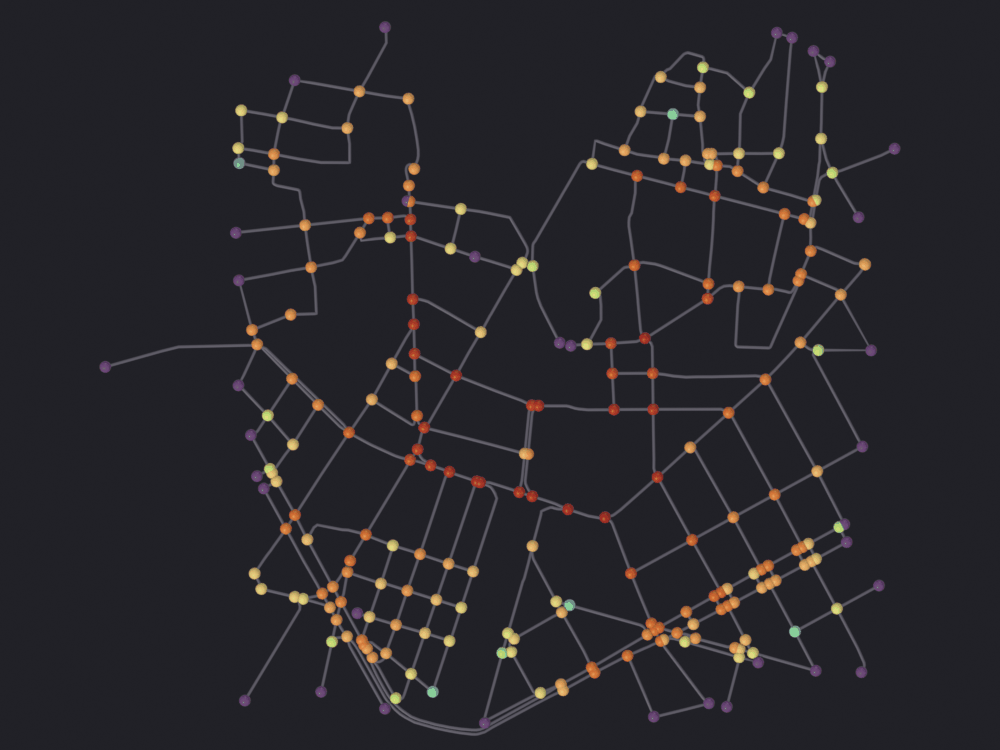

[PASS] 1_betweenness_raw.png legible — 9.3% ink (healthy range 0.5–60%)


True

In [15]:
filled, array = node_attribute(net, reference_weighted, "node_betweenness")
print(f"node_betweenness: {filled} intersections written, "
      f"{len(array)} vertices, range 0 … {array.max():.4f}")
print("domain:", sg.render.attribute_domain(net, "node_betweenness"))

raw = nb.render(net, "renders/10_centrality/1_betweenness_raw",
                look='ink', color_attribute="node_betweenness",
                verbose=False)
nb.show(raw)
nb.check_render(raw)

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_betweenness  ·  node_betweenness -> turbo [log]  [0 … 0.2266] on Point


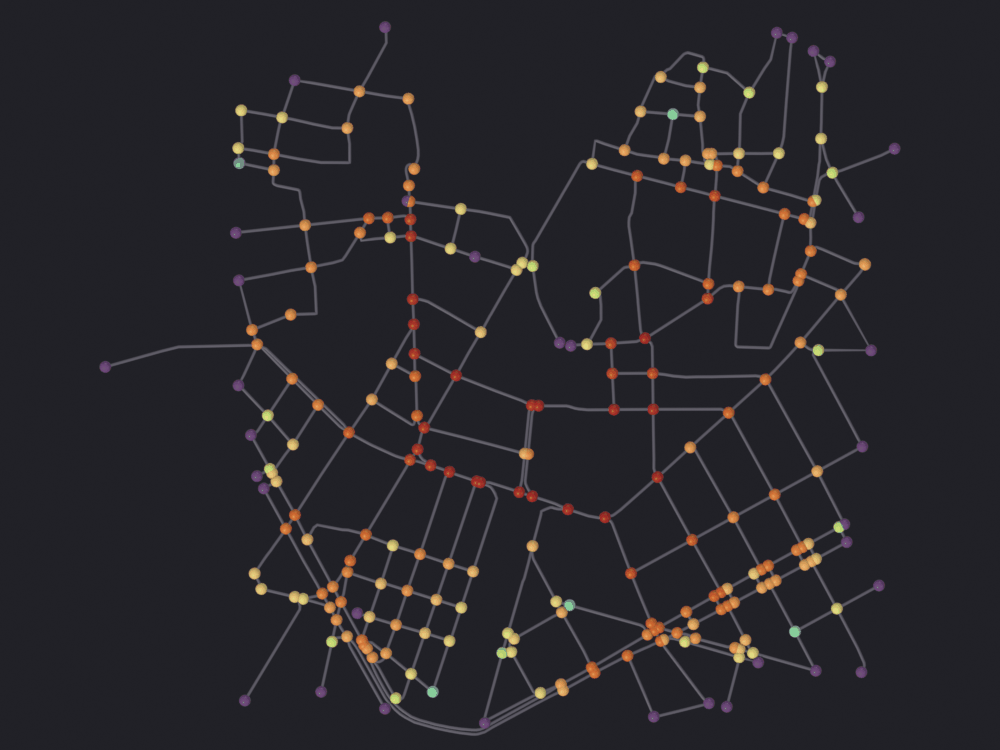

[PASS] 2_betweenness_clipped.png legible — 9.3% ink (healthy range 0.5–60%)
ink without the clip 9.290%
ink with it          9.284%
pixels the clip moved: 1.10%


In [16]:
clipped = nb.render(
    net, "renders/10_centrality/2_betweenness_clipped",
    look='ink', color_attribute="node_betweenness", clip_high_pct=98,
    verbose=False)
nb.show(clipped)
nb.check_render(clipped)

print(f"ink without the clip {nb.ink(raw):.3%}")
print(f"ink with it          {nb.ink(clipped):.3%}")


def plates_differ(first, second, threshold=8):
    """Fraction of pixels whose color differs between two renders.

    `nb.ink()` counts pixels that are not background and cannot see a
    recoloring; this can.
    """
    from PIL import Image

    a = np.asarray(Image.open(str(first)).convert("RGB"), dtype=np.int16)
    b = np.asarray(Image.open(str(second)).convert("RGB"), dtype=np.int16)
    return float((np.abs(a - b).max(axis=2) > threshold).mean())


print(f"pixels the clip moved: {plates_differ(raw, clipped):.2%}")

**`check_render` cannot see the difference.** The ink fractions
agree to a thousandth, as they should: clipping moves colors without
changing how many pixels carry them. Hence `plates_differ`, which can.

It is needed for a second reason: **a graph object keeps its previous
coloring.** `sg.render.material()` will not overwrite an existing
`*_SciGraphsColor` material (`notebooks/tools/sg.render.py:736-740`) and
rewires the existing color layer when it does build one (`:759-765`), so
rendering one object repeatedly under different `color_attribute=` values can
hand you the first coloring six times. This notebook renders one network
under six quantities, so every comparison below is checked rather than
assumed.

On *this* network the clip does very little. `max / p98` is about 1.1, so the
top two percent of the scale was carrying almost nothing; reclaiming it
moves the busiest corridor from orange to red. On a bigger network, where one
motorway takes an order of magnitude more than the 98th percentile, the same
argument returns most of the ramp.

### What the default actually draws

The unweighted answer that section 2 measured, on the same network. The point
of the figure is that **it is not obviously wrong**.

The two frames cannot be compared stop for stop. `vmin=`/`vmax=` are silently
ineffective on this path: `scigraphs.color_set_attribute` calls
`fn.update_property_range()` before reading them
(`SciGraphs/ui/coloring/operators.py:374`) and overwrites whatever was
passed, so there is no way to pin the two renders to one absolute scale. Each
has its own ramp over its own range; the comparison that means anything is
the rank table in section 2.

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_betweenness_fast  ·  node_betweenness_fast -> turbo [log]  [0 … 0.2171] on Point


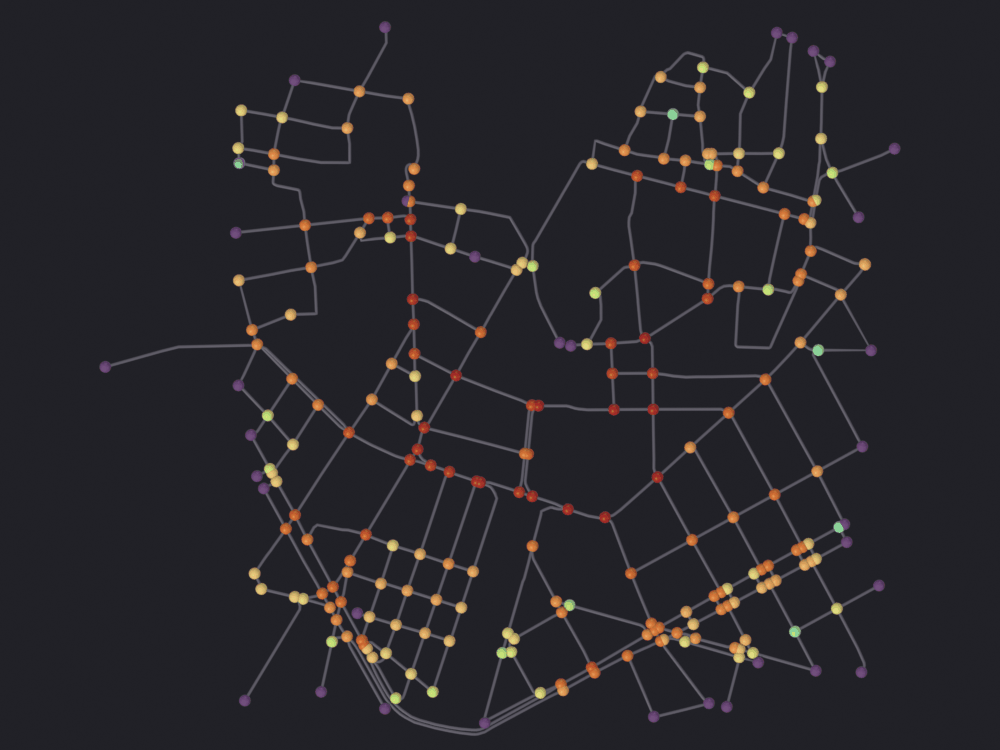

[PASS] 3_betweenness_default.png legible — 9.3% ink (healthy range 0.5–60%)
pixels differing between the weighted plate and this one: 1.59%
[PASS] the two plates really are two colorings — if this were 0 the renderer would be reusing the first material, not the measures agreeing


True

In [17]:
node_attribute(net, fast_length, "node_betweenness_fast")

default_plate = nb.render(
    net, "renders/10_centrality/3_betweenness_default", look='ink',
    color_attribute="node_betweenness_fast", clip_high_pct=98, verbose=False)
nb.show(default_plate)
nb.check_render(default_plate)

moved = plates_differ(clipped, default_plate)
print(f"pixels differing between the weighted plate and this one: {moved:.2%}")

check("the two plates really are two colorings",
      moved > 0.005,
      "if this were 0 the renderer would be reusing the first material, "
      "not the measures agreeing")

## 4 · Betweenness of streets, not of intersections

The part of `osmnx_centrality` that has no generic equivalent.
`edge_betweenness_line` collapses the multigraph to a simple `DiGraph`, takes
its **line graph** (the graph whose nodes are the original's edges, joined
when they meet) and runs node betweenness on that
(`core/osmnx/centrality.py:110-137`). Node betweenness on the line graph *is*
edge betweenness on the original, and the result is indexed by `(u, v)`: one
number per street segment.

The standard move in street-network analysis, and not a presentational
choice. "Which junction do the through routes pass?" and "which street do
they run along?" have different answers on any network with blocks, because a
route entering a junction and leaving it again scores the junction once and
two different streets. The second is the question a street is planned around.

In [18]:
t0 = time.time()
edge_bw = sg_centrality.edge_betweenness_line(G, weight="length", fast=True)
print(f"edge_betweenness_line: {len(edge_bw)} segments in {time.time() - t0:.2f} s")
print(f"  keyed by {type(next(iter(edge_bw)))}, "
      f"for example {next(iter(edge_bw))}")

values = np.array(list(edge_bw.values()))
print("\nstreet betweenness")
for p in (50, 75, 90, 95, 98, 100):
    print(f"  p{p:<3} {np.percentile(values, p):.4f}")
ranked_e = np.sort(values)[::-1]
for share in (5, 10):
    take = max(1, len(ranked_e) * share // 100)
    print(f"  top {share:>2} % of streets carry "
          f"{ranked_e[:take].sum() / ranked_e.sum():.1%} of the total")

check("there is one value per street segment",
      len(edge_bw) <= G.number_of_edges())

edge_betweenness_line: 375 segments in 0.01 s
  keyed by <class 'tuple'>, for example (25767293, 25767446)

street betweenness
  p50  0.0175
  p75  0.0407
  p90  0.0849
  p95  0.1274
  p98  0.1788
  p100 0.2634
  top  5 % of streets carry 26.0% of the total
  top 10 % of streets carry 42.5% of the total
[PASS] there is one value per street segment


True

### The operator computes it and then throws it away

Run `osmnx_centrality` with `kind='BETWEENNESS_EDGE'` and it reports success,
names a range in the status bar, and writes an `EDGE` attribute that is
**entirely zero**.

In [19]:
print("osmnx_centrality BETWEENNESS_EDGE ->",
      bpy.ops.scigraphs.osmnx_centrality(kind='BETWEENNESS_EDGE',
      weighted=True, fast=True))

written = np.array([d.value for d in net.data.attributes["edge_betweenness"].data])
print(f"  attribute domain  {net.data.attributes['edge_betweenness'].domain}")
print(f"  length            {len(written)} (mesh edges)")
print(f"  non-zero values   {int((written != 0).sum())}")
print(f"  the operator reported a range of "
      f"[{min(edge_bw.values()):.4f}, {max(edge_bw.values()):.4f}]")

# The values did reach the graph, which is where the color operators cannot
# see them.
on_graph = sum(1 for *_ids, d in G_after.edges(data=True)
               if "edge_betweenness" in d)
print(f"  segments carrying it on the NetworkX graph: {on_graph}")

check("the EDGE mesh attribute is all zeros", int((written != 0).sum()) == 0,
      "computed, stored on the graph, and then not transferred")

Info: edge_betweenness: 375 values, range [0.0000, 0.2634]
osmnx_centrality BETWEENNESS_EDGE -> {'FINISHED'}
  attribute domain  EDGE
  length            1492 (mesh edges)
  non-zero values   0
  the operator reported a range of [0.0000, 0.2634]
  segments carrying it on the NetworkX graph: 375
[PASS] the EDGE mesh attribute is all zeros — computed, stored on the graph, and then not transferred


True

> **Defect.** `centrality_operators.py:120-127` creates the
> `EDGE` attribute and fills it with a literal `0.0` in a loop, under a
> comment saying the edge-to-`(u, v)` mapping depends on
> `core.osmnx.mesh_bridge`. That module already does the job:
> `mesh_bridge.transfer_edge_attribute_to_mesh(obj, G, name)` resolves a
> graph edge to the run of mesh edges that draws it, which is not one-to-one
> because `retain_geometry` splits every street into several. The
> operator has already put the values on `G` two lines earlier
> (`centrality_operators.py:101-104`), so the fix is to call it.
>
> Nothing reports the failure. `osmnx_attr_to_colors` on an `EDGE` attribute
> paints every loop `(0.5, 0.5, 0.5)` regardless
> (`centrality_operators.py:203-207`), the path notebook 07 §6 covers, and
> the status bar quotes the range of the values that never arrived.

In [20]:
transferred = mesh_bridge.transfer_edge_attribute_to_mesh(
    net, G_after, "edge_betweenness", mesh_attr_name="street_betweenness")
street = np.array([d.value for d in net.data.attributes["street_betweenness"].data])

print(f"transfer_edge_attribute_to_mesh -> {transferred} assignments")
print(f"  mesh edges with a value  {int((street != 0).sum())} of {len(street)}")
print(f"  range                    0 … {street.max():.4f}")
print(f"  domain                   "
      f"{sg.render.attribute_domain(net, 'street_betweenness')}")

coverage = (street != 0).sum() / len(street)
print(f"\ncoverage {coverage:.1%}: the shortfall is "
      f"`build_edge_mapping`'s breadth-first search failing to find a path "
      f"through the shape points for some segments; those mesh edges keep 0.0 "
      f"and sit at the bottom of the ramp")

check("the transfer reaches most of the mesh", coverage > 0.8,
      f"{int((street != 0).sum())} of {len(street)} mesh edges")

transfer_edge_attribute_to_mesh -> 1565 assignments
  mesh edges with a value  1315 of 1492
  range                    0 … 0.2634
  domain                   EDGE

coverage 88.1%: the shortfall is `build_edge_mapping`'s breadth-first search failing to find a path through the shape points for some segments; those mesh edges keep 0.0 and sit at the bottom of the ramp
[PASS] the transfer reaches most of the mesh — 1315 of 1492 mesh edges


True

### The figure, and what it is really showing

**There is no per-edge color on a graph.** A color attribute lives on
`POINT` or on `CORNER`, a graph mesh has no faces, so an `EDGE` attribute is
averaged over the edges meeting at each vertex before it reaches the shader
(`SciGraphs/core/mesh/attributes.py:227`). What follows is a
*vertex-averaged* field. Notebook 07 quantifies the cost on an OSMnx import:
three quarters of the vertices are shape points interior to a single street
and take that street's exact value, so the averaging happens only at
junctions. Read the tubes, not the joints.

  Promoted 2 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> street_betweenness  ·  street_betweenness -> turbo [log]  [0 … 0.1854] on Point


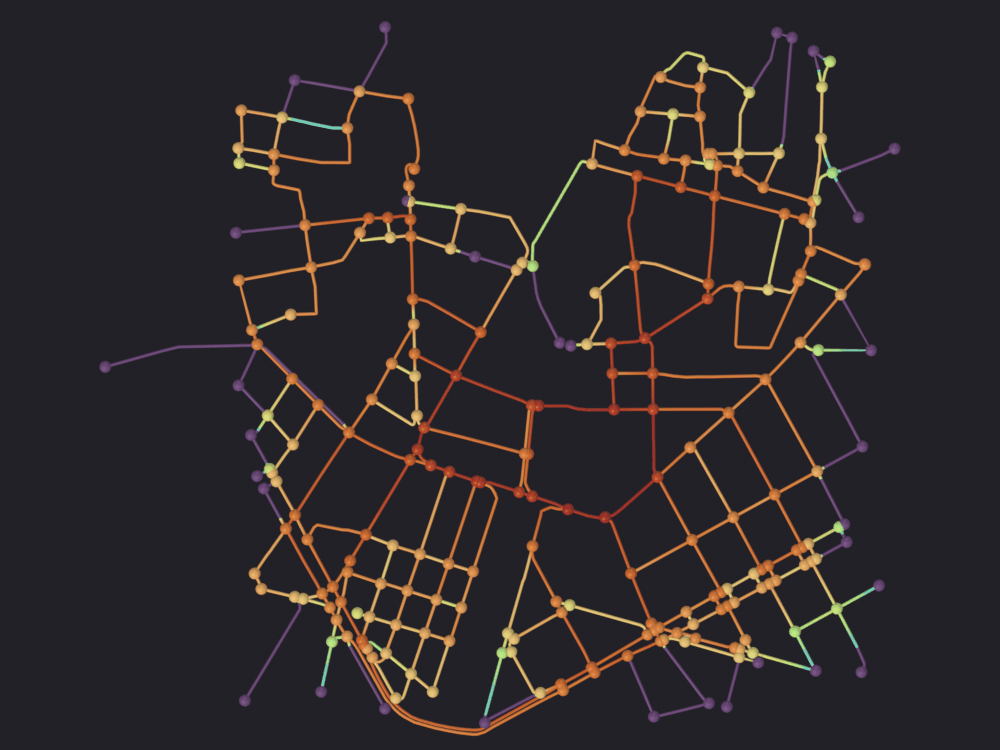

[PASS] 4_street_betweenness.png legible — 9.8% ink (healthy range 0.5–60%)
pixels differing from the junction plate: 8.66%
[PASS] the tubes are carrying the color now, not just the spheres — an EDGE attribute is promoted to POINT for the shader, which is what puts a value on every vertex along a street


True

In [21]:
street_plate = nb.render(
    net, "renders/10_centrality/4_street_betweenness", look='ink',
    color_attribute="street_betweenness", clip_high_pct=98, verbose=False)
nb.show(street_plate)
nb.check_render(street_plate)

print(f"pixels differing from the junction plate: "
      f"{plates_differ(clipped, street_plate):.2%}")

check("the tubes are carrying the color now, not just the spheres",
      plates_differ(clipped, street_plate) > 0.02,
      "an EDGE attribute is promoted to POINT for the shader, which is "
      "what puts a value on every vertex along a street")

Figure 2 and this one do not name the same winner. Node
betweenness lights the junctions along the corridor most routes have to
enter; street betweenness lights the run of carriageway they then follow. If
the question is where to put a crossing, it is the junction figure; if it is
which street cannot be closed, this one.

Notebook 08 builds a third answer by routing a few hundred
origin-destination pairs and counting how many routes use each edge. That
count is a Monte-Carlo approximation of this quantity on a sample of pairs,
useful when the exact computation is too slow. It is not rebuilt here.

In [22]:
print(f"busiest intersection  betweenness {WEIGHTED.max():.4f}")
busiest_edge = max(edge_bw, key=edge_bw.get)
data = G.get_edge_data(*busiest_edge)
name = next((d.get("name") for d in data.values() if d.get("name")), "unnamed")
print(f"busiest street        {name}  betweenness {edge_bw[busiest_edge]:.4f}")

busiest intersection  betweenness 0.2573
busiest street        Carrer de Xàtiva  betweenness 0.2634


## 5 · Closeness, where the same defect is unmissable

Closeness is the reciprocal of the mean distance to everywhere else, so on a
compact study area it is a smooth gradient peaking near the centroid rather
than a set of corridors. That also makes it the measure most sensitive to
where you cut the study area, and the one to distrust on a truncated graph.

It shares section 2's defect: `node_closeness` hands the weights to
`rx.closeness_centrality` (`centrality.py:163`), which does not take them.
Here the two answers are not even in the same units. Weighted, the distances
are **meters** and closeness comes out around 1/1000; unweighted they are
**hops** and it comes out around 1/12. Two numbers eighty times apart, from
one checkbox, both labeled `closeness`.

In [23]:
close_fast = sg_centrality.node_closeness(G, weight="length", fast=True)
close_slow = sg_centrality.node_closeness(G, weight="length", fast=False)
CF = np.array([close_fast[n] for n in order])
CS = np.array([close_slow[n] for n in order])

print(f"closeness, fast vs slow: identical = {np.allclose(CF, CS)}")
print(f"  fast=True  (hops)   range 0 … {CF.max():.5f}, mean {CF.mean():.5f}")
print(f"  fast=False (meters) range 0 … {CS.max():.5f}, mean {CS.mean():.5f}")
print(f"  ratio of the two means           {CF.mean() / CS.mean():.0f}x")
print(f"  Spearman between them            {spearmanr(CF, CS).statistic:.4f}")

check("closeness has the same weight defect",
      not np.allclose(CF, CS))
check("and the two are not even on the same scale",
      CF.mean() > 10 * CS.mean(),
      "reciprocal meters against reciprocal hops")

closeness, fast vs slow: identical = False
  fast=True  (hops)   range 0 … 0.08640, mean 0.05593
  fast=False (meters) range 0 … 0.00101, mean 0.00067
  ratio of the two means           84x
  Spearman between them            0.8693
[PASS] closeness has the same weight defect
[PASS] and the two are not even on the same scale — reciprocal meters against reciprocal hops


True

The figure takes the metric one, and it needs the *opposite*
clip from the betweenness figures. Closeness has no long upper tail (it is
bounded above by the most central node) but it has a long **lower** one, and
on a directed graph the bottom of that tail is exactly zero: a node that
nothing can reach has no finite distance to average, and the far end of a
one-way stub is such a node. Those sit at the ramp's first stop and take
everything between there and the bulk with them.

intersections with closeness exactly 0: 15
  their in-degree: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], nothing reaches them
  the rest run 3.76e-05 … 1.01e-03
  Promoted 2 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_closeness  ·  node_closeness -> turbo [log]  [0 … 0.001009] on Point


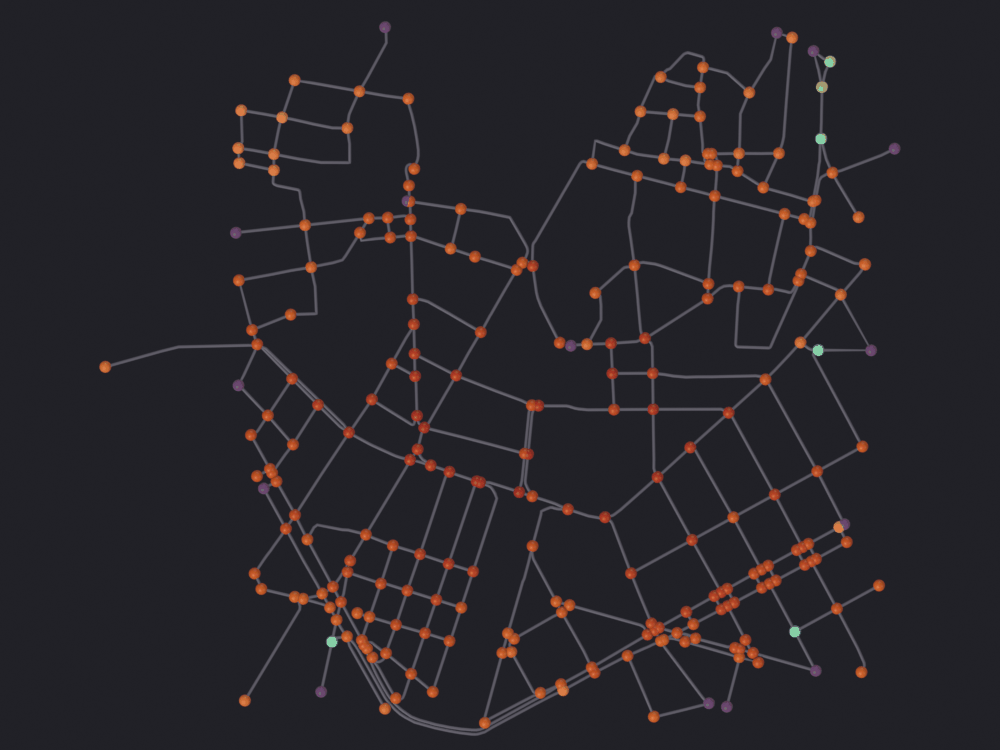

[PASS] 5_closeness_raw.png legible — 9.2% ink (healthy range 0.5–60%)


True

In [24]:
zero_nodes = [n for n in order if close_slow[n] == 0.0]
print(f"intersections with closeness exactly 0: {len(zero_nodes)}")
print(f"  their in-degree: "
      f"{[G.in_degree(n) for n in zero_nodes]}, nothing reaches them")
print(f"  the rest run {min(v for v in CS if v > 0):.2e} … {CS.max():.2e}")

filled_c, mesh_closeness = node_attribute(net, close_slow, "node_closeness")

unclipped = nb.render(
    net, "renders/10_centrality/5_closeness_raw", look='ink',
    color_attribute="node_closeness", verbose=False)
nb.show(unclipped)
nb.check_render(unclipped)

The clip is computed over the **mesh** attribute, not the 243
node values: every vertex is a sample, and three quarters of them are street
shape carrying the mean of the two intersections at either end. So the
percentile that decides the ramp has to be read off the same array the
renderer reads.

mesh attribute: 1374 values, 15 of them exactly 0
  2nd percentile 1.015e-04, median 7.164e-04, max 1.009e-03
  clipping there returns 10 % of the ramp to the rest
  Promoted 2 edge attribute(s) to point domain for GN propagation
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_closeness  ·  node_closeness -> turbo [log]  [0.0001015 … 0.001009] on Point


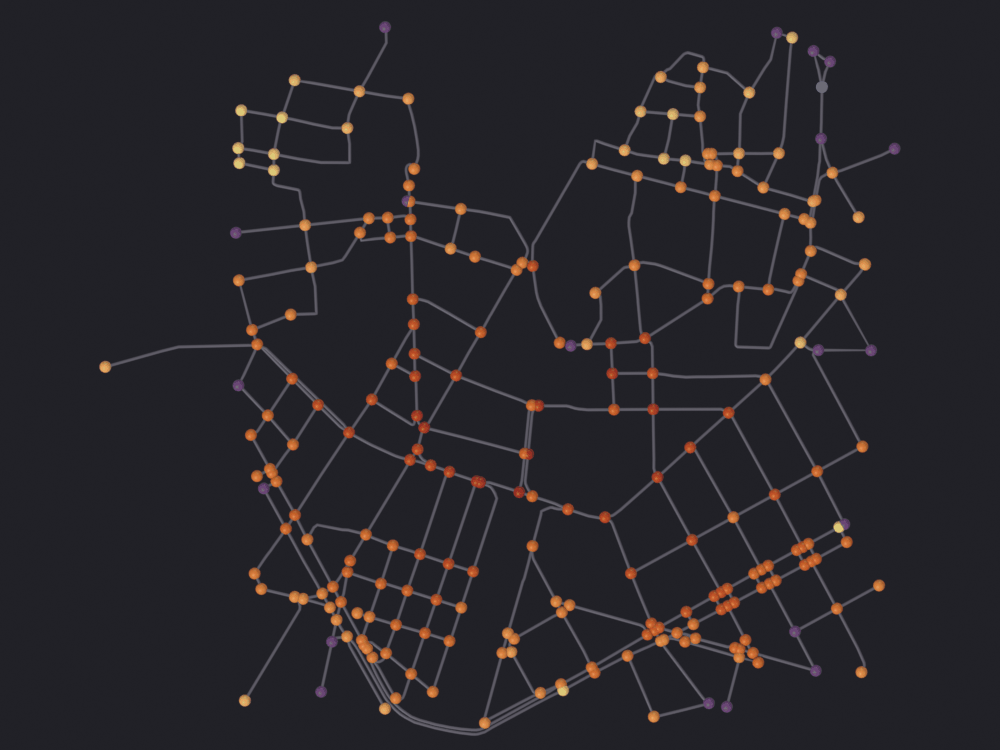

[PASS] 6_closeness.png legible — 9.3% ink (healthy range 0.5–60%)
ink unclipped 9.227%, clipped 9.308%
pixels the low clip moved: 3.44%
[PASS] clipping the bottom repaints a large part of the map — and the ink number, as always, is unchanged


True

In [25]:
low = np.percentile(mesh_closeness, 2)
print(f"mesh attribute: {len(mesh_closeness)} values, "
      f"{int((mesh_closeness == 0).sum())} of them exactly 0")
print(f"  2nd percentile {low:.3e}, median {np.median(mesh_closeness):.3e}, "
      f"max {mesh_closeness.max():.3e}")
print(f"  clipping there returns "
      f"{100 * low / mesh_closeness.max():.0f} % of the ramp to the rest")

close_plate = nb.render(
    net, "renders/10_centrality/6_closeness", look='ink',
    color_attribute="node_closeness", clip_low_pct=2, verbose=False)
nb.show(close_plate)
nb.check_render(close_plate)

print(f"ink unclipped {nb.ink(unclipped):.3%}, clipped "
      f"{nb.ink(close_plate):.3%}")
print(f"pixels the low clip moved: {plates_differ(unclipped, close_plate):.2%}")

check("clipping the bottom repaints a large part of the map",
      plates_differ(unclipped, close_plate) > 0.01,
      "and the ink number, as always, is unchanged")

## 6 · Export: what survives

All but one of the eight routes produce a file; the question is whether the
numbers are in it, and whether they are still numbers when they come back.
Notebook 06 §7 covers the *topology* round trip: `graph_to_gdfs`,
`osmnx_graph_to_gdfs`, and why GeoJSON turns every scalar tag into a
one-element list. This section is about the attributes **this notebook
computed**, which nothing downstream has heard of.

* `scigraphs.export_graph` reads the **mesh**: topology through
  `parse_graph_data_filtered`, attributes through `collect_mesh_attributes`,
  which takes `POINT`-domain numeric attributes and nothing else
  (`core/mesh/mesh_utils.py:209-233`). GraphML, GEXF, JSON, CSV.
* `scigraphs.osmnx_export` reads the **`MultiDiGraph`** and hands it straight
  to OSMnx. GeoPackage, OSM XML, Gephi GraphML, SVG.

So an `EDGE` attribute cannot leave through the first, and a mesh attribute
cannot leave through the second. Nothing says so.

In [26]:
out_dir = nb.out("14_centrality")
out_dir.mkdir(parents=True, exist_ok=True)

# Both places the quantity can live.
for node_id, value in reference_weighted.items():
    G_after.nodes[node_id]["betweenness_w"] = float(value)
node_attribute(net, reference_weighted, "betweenness_w")

survives = {}

point_attrs = [n for n, d, _ in sg.graphs.attributes(net) if d == 'POINT']
edge_attrs = [n for n, d, _ in sg.graphs.attributes(net)
              if d == 'EDGE' and not n.startswith(".")]
graph_node_keys = set()
for _n, d in G_after.nodes(data=True):
    graph_node_keys |= set(d)

print("what is on the object before anything is written")
print(f"  mesh POINT attributes  {point_attrs}")
print(f"  mesh EDGE attributes   {edge_attrs}")
print(f"  graph node attributes  {sorted(graph_node_keys)}")

color_layers = [n for n in point_attrs if n.endswith("_color")]
print(f"\n{len(color_layers)} of those POINT attributes are color layers "
      f"the renderer left behind:")
print(f"  {color_layers}")

check("drawing a figure adds a POINT attribute per attribute drawn",
      len(color_layers) >= 4,
      "one `<name>_color` layer per `color_attribute=` this notebook used")

what is on the object before anything is written
  mesh POINT attributes  ['is_intersection', 'position', 'betweenness', 'centrality_betweenness', 'node_betweenness', 'node_betweenness_color', 'node_betweenness_fast', 'node_betweenness_fast_color', 'street_betweenness_color', 'node_closeness', 'node_closeness_color', 'betweenness_w']
  mesh EDGE attributes   ['edge_betweenness', 'street_betweenness']
  graph node attributes  ['betweenness', 'betweenness_w', 'highway', 'street_count', 'x', 'y']

4 of those POINT attributes are color layers the renderer left behind:
  ['node_betweenness_color', 'node_betweenness_fast_color', 'street_betweenness_color', 'node_closeness_color']
[PASS] drawing a figure adds a POINT attribute per attribute drawn — one `<name>_color` layer per `color_attribute=` this notebook used


True

> **Worth knowing before the tables below.**
> `collect_mesh_attributes` takes every numeric `POINT` attribute, and
> `FLOAT_COLOR` counts: it averages each RGBA to a scalar and exports it like
> any other measurement (`core/mesh/mesh_utils.py:222-228`). A graph that has
> been *drawn* therefore exports its own color ramp alongside its data, one
> extra node attribute per figure, named `node_betweenness_color` beside
> `node_betweenness`. Nothing marks which is which. Name the attribute you
> want and drop the rest on the way in.

### `scigraphs.export_graph`, four formats

In [27]:
props.export_include_attributes = True
written_files = {}

for fmt, ext in (('GRAPHML', '.graphml'), ('GEXF', '.gexf'),
                 ('JSON', '.json'), ('CSV', '.csv')):
    path = out_dir / f"export_graph{ext}"
    props.export_format = fmt
    props.export_filepath = str(path)
    try:
        result = bpy.ops.scigraphs.export_graph()
    except RuntimeError as exc:
        print(f"  {fmt:<8} failed: {exc}")
        continue
    written_files[fmt] = path
    status = "ok" if 'FINISHED' in result else "canceled"
    print(f"  {fmt:<8} {status:<10} {path.name:<22} "
          f"{path.stat().st_size / 1e3:>7.1f} kB")

Info: Graph exported to notebooks/out/14_centrality/export_graph.graphml
  GRAPHML  ok         export_graph.graphml     194.9 kB
Info: Graph exported to notebooks/out/14_centrality/export_graph.gexf
  GEXF     ok         export_graph.gexf        246.2 kB
Info: Graph exported to notebooks/out/14_centrality/export_graph.json
  JSON     ok         export_graph.json        173.6 kB
Info: Graph exported to notebooks/out/14_centrality/export_graph.csv
  CSV      ok         export_graph.csv           7.2 kB


In [28]:
back = nx.read_graphml(str(written_files['GRAPHML']))
node_keys = set()
for _n, d in back.nodes(data=True):
    node_keys |= set(d)
edge_keys = set()
for _u, _v, d in back.edges(data=True):
    edge_keys |= set(d)

print(f"GraphML  {back.number_of_nodes()} nodes, {back.number_of_edges()} edges, "
      f"directed={back.is_directed()}")
print(f"         node attributes {sorted(node_keys)}")
print(f"         edge attributes {sorted(edge_keys) or '(none)'}")

worst = max(abs(float(back.nodes[nid]["betweenness_w"]) - reference_weighted[int(nid)])
            for nid in back.nodes if "betweenness_w" in back.nodes[nid])
print(f"         largest error in betweenness_w: {worst:.3e}")

survives['export_graph GraphML'] = dict(
    nodes=back.number_of_nodes(), edges=back.number_of_edges(),
    directed=back.is_directed(), node_attr="betweenness_w" in node_keys,
    edge_attr=bool(edge_keys), error=worst)

check("GraphML carries the computed node attribute",
      "betweenness_w" in node_keys)
check("and loses the direction of every one-way",
      not back.is_directed() and G.is_directed(),
      "the source graph is a MultiDiGraph")

GraphML  243 nodes, 375 edges, directed=False
         node attributes ['betweenness', 'betweenness_w', 'centrality_betweenness', 'is_intersection', 'node_betweenness', 'node_betweenness_color', 'node_betweenness_fast', 'node_betweenness_fast_color', 'node_closeness', 'node_closeness_color', 'street_betweenness_color']
         edge attributes (none)
         largest error in betweenness_w: 1.447e-08
[PASS] GraphML carries the computed node attribute
[PASS] and loses the direction of every one-way — the source graph is a MultiDiGraph


True

> **Defect.** `export_to_graphml` writes
> `edgedefault="directed"` only when `hasattr(graph_data, 'is_directed')`
> (`core/data_io/export_utils.py:25`), and `GraphData` has no such
> attribute: it is three fields wide (`core/algorithms/graph.py:3`). The
> condition is false for every graph the add-on can produce, so every GraphML
> and GEXF export comes out undirected. `export_to_json` has the same
> expression at `export_utils.py:148` and writes `"directed": false` beside
> it. Meanwhile `create_osmnx_graph_mesh` stores the answer on the object as
> `obj["is_directed"]` (`core/mesh/geometry.py:1755`) and nothing on the
> export path reads it.
>
> Every one-way in Ciutat Vella comes back as a two-way, and any betweenness
> recomputed downstream from the exported file is a different quantity from
> the one exported with it.

The values lose precision too: the mesh stores a `FLOAT` attribute in single
precision, so anything routed through it comes back with about seven
significant digits. Irrelevant for a centrality, fatal for a coordinate,
which is why nothing in this suite moves geometry that way.

In [29]:
gexf = nx.read_gexf(str(written_files['GEXF']))
gexf_keys = set()
for _n, d in gexf.nodes(data=True):
    gexf_keys |= set(d)
print(f"GEXF     {gexf.number_of_nodes()} nodes, {gexf.number_of_edges()} edges, "
      f"directed={gexf.is_directed()}")
print(f"         node attributes {sorted(gexf_keys)}")
survives['export_graph GEXF'] = dict(
    nodes=gexf.number_of_nodes(), edges=gexf.number_of_edges(),
    directed=gexf.is_directed(), node_attr="betweenness_w" in gexf_keys,
    edge_attr=False, error=None)

payload = json.loads(written_files['JSON'].read_text(encoding="utf-8"))
first = payload["nodes"][0]
print(f"\nJSON     {len(payload['nodes'])} nodes, {len(payload['edges'])} edges, "
      f"directed={payload['directed']}")
print(f"         first node {json.dumps(first)[:110]} …")
print(f"         edges carry {sorted(payload['edges'][0])}")
survives['export_graph JSON'] = dict(
    nodes=len(payload["nodes"]), edges=len(payload["edges"]),
    directed=payload["directed"],
    node_attr="betweenness_w" in first.get("attributes", {}),
    edge_attr=False, error=None)

lines = written_files['CSV'].read_text(encoding="utf-8").splitlines()
print(f"\nCSV      {len(lines) - 1} rows, header {lines[0]!r}, "
      f"first row {lines[1]!r}")
survives['export_graph CSV'] = dict(
    nodes=None, edges=len(lines) - 1, directed=None,
    node_attr=False, edge_attr=False, error=None)

check("CSV is an edge list and nothing else",
      lines[0] == "source,target",
      "`export_to_csv_edges` writes two columns and ignores "
      "`export_include_attributes` entirely (export_utils.py:181-205)")

GEXF     243 nodes, 375 edges, directed=False
         node attributes ['betweenness', 'betweenness_w', 'centrality_betweenness', 'is_intersection', 'label', 'node_betweenness', 'node_betweenness_color', 'node_betweenness_fast', 'node_betweenness_fast_color', 'node_closeness', 'node_closeness_color', 'street_betweenness_color']

JSON     243 nodes, 375 edges, directed=False
         first node {"id": "25767293", "attributes": {"is_intersection": 1.0, "betweenness": 0.25429973006248474, "centrality_betw …
         edges carry ['source', 'target']

CSV      375 rows, header 'source,target', first row '25767293,25767446'
[PASS] CSV is an edge list and nothing else — `export_to_csv_edges` writes two columns and ignores `export_include_attributes` entirely (export_utils.py:181-205)


True

### `scigraphs.osmnx_export`, four formats

A better result, because it does not go through the mesh at all: whatever is
on the `MultiDiGraph` is what OSMnx serializes, and OSMnx has been carrying
arbitrary node and edge attributes for years.

In [30]:
osmnx_files = {}
for fmt, ext in (('GEOPACKAGE', '.gpkg'), ('OSM_XML', '.osm'),
                 ('GRAPHML_GEPHI', '.graphml'), ('SVG', '.svg')):
    path = out_dir / f"osmnx_{fmt.lower()}{ext}"
    props.osmnx_export_format = fmt
    try:
        result = bpy.ops.scigraphs.osmnx_export(filepath=str(path))
    except RuntimeError as exc:
        message = str(exc).strip().splitlines()[-1]
        print(f"  {fmt:<14} FAILED: {message}")
        survives[f'osmnx_export {fmt}'] = dict(
            nodes=None, edges=None, directed=None,
            node_attr=False, edge_attr=False, error="refused")
        continue
    osmnx_files[fmt] = path
    print(f"  {fmt:<14} {'ok':<10} {path.name:<28} "
          f"{path.stat().st_size / 1e3:>7.1f} kB")

Info: Saved GeoPackage: osmnx_geopackage.gpkg
  GEOPACKAGE     ok         osmnx_geopackage.gpkg          266.2 kB
Error: OSM XML export failed: Graph must be unsimplified to save as OSM XML.
  OSM_XML        FAILED: Error: OSM XML export failed: Graph must be unsimplified to save as OSM XML.
Info: Saved Gephi GraphML: osmnx_graphml_gephi.graphml
  GRAPHML_GEPHI  ok         osmnx_graphml_gephi.graphml    269.1 kB
Info: Saved SVG: osmnx_svg.svg
  SVG            ok         osmnx_svg.svg                   87.3 kB


`OSM_XML` refuses a simplified graph, and that is OSMnx being
correct rather than the operator being broken: OSM XML describes ways as
sequences of nodes, and a simplified graph has thrown away the nodes interior
to a way. Use it to feed the download back to a routing engine, and only from
`osmnx_simplify`-untouched data. Notebook 06 §4 keeps such a graph around.

In [31]:
gephi = nx.read_graphml(str(osmnx_files['GRAPHML_GEPHI']))
g_nodes, g_edges = set(), set()
for _n, d in gephi.nodes(data=True):
    g_nodes |= set(d)
for _u, _v, d in gephi.edges(data=True):
    g_edges |= set(d)
sample = gephi.nodes[next(iter(gephi.nodes))]

print(f"Gephi GraphML  {gephi.number_of_nodes()} nodes, "
      f"{gephi.number_of_edges()} edges, directed={gephi.is_directed()}")
print(f"  node attributes {sorted(g_nodes)}")
print(f"  edge attributes {sorted(g_edges)}")
print(f"  and their types {[type(v).__name__ for v in sample.values()]}")
survives['osmnx_export Gephi GraphML'] = dict(
    nodes=gephi.number_of_nodes(), edges=gephi.number_of_edges(),
    directed=gephi.is_directed(), node_attr="betweenness_w" in g_nodes,
    edge_attr=bool(g_edges), error=None)

check("the Gephi export carries every node and edge attribute",
      "betweenness_w" in g_nodes and "length" in g_edges)
check("and every value in it is a string",
      all(isinstance(v, str) for v in sample.values()),
      "GraphML with `gephi=True` writes no types; the reader has to "
      "be told what each column is")

Gephi GraphML  243 nodes, 375 edges, directed=True
  node attributes ['betweenness', 'betweenness_w', 'highway', 'street_count', 'x', 'y']
  edge attributes ['access', 'edge_betweenness', 'geometry', 'highway', 'id', 'junction', 'lanes', 'length', 'maxspeed', 'name', 'oneway', 'osmid', 'reversed', 'tunnel', 'width']
  and their types ['str', 'str', 'str', 'str', 'str']
[PASS] the Gephi export carries every node and edge attribute
[PASS] and every value in it is a string — GraphML with `gephi=True` writes no types; the reader has to be told what each column is


True

In [32]:
import geopandas as gpd
import pandas as pd

gpkg = osmnx_files['GEOPACKAGE']
gpkg_nodes = gpd.read_file(str(gpkg), layer="nodes")
gpkg_edges = gpd.read_file(str(gpkg), layer="edges")
print(f"GeoPackage  layers nodes({len(gpkg_nodes)}) and edges({len(gpkg_edges)})")
print(f"  node columns {list(gpkg_nodes.columns)}")
print(f"  edge columns {list(gpkg_edges.columns)}")
if "betweenness_w" in gpkg_nodes.columns:
    stored = gpkg_nodes.set_index("osmid")["betweenness_w"]
    wanted = pd.Series(reference_weighted).reindex(stored.index)
    error = float((stored - wanted).abs().max())
    print(f"  betweenness_w survives, largest error {error:.3e}, "
          f"dtype {stored.dtype}")

print(f"\n  the graph has {G.number_of_edges()} directed segments; the file "
      f"has {len(gpkg_edges)} rows")
print(f"  and carries {sorted(set(gpkg_edges.columns) & {'oneway', 'from', 'to', 'reversed'})}")

survives['osmnx_export GeoPackage'] = dict(
    nodes=len(gpkg_nodes), edges=len(gpkg_edges),
    directed=len(gpkg_edges) == G.number_of_edges(),
    node_attr="betweenness_w" in gpkg_nodes.columns,
    edge_attr="length" in gpkg_edges.columns, error=None)

check("the GeoPackage keeps the computed attribute as a real float",
      "betweenness_w" in gpkg_nodes.columns
      and gpkg_nodes["betweenness_w"].dtype.kind == "f")
check("but it is written undirected",
      len(gpkg_edges) < G.number_of_edges(),
      f"{G.number_of_edges() - len(gpkg_edges)} reciprocal pairs "
      "collapsed into single rows")

GeoPackage  layers nodes(243) and edges(363)
  node columns ['osmid', 'y', 'x', 'street_count', 'betweenness', 'betweenness_w', 'highway', 'geometry']
  edge columns ['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'edge_betweenness', 'from', 'to', 'width', 'junction', 'tunnel', 'access', 'geometry']
  betweenness_w survives, largest error 0.000e+00, dtype float64

  the graph has 375 directed segments; the file has 363 rows
  and carries ['from', 'oneway', 'reversed', 'to']
[PASS] the GeoPackage keeps the computed attribute as a real float
[PASS] but it is written undirected — 12 reciprocal pairs collapsed into single rows


True

> **Defect, and the qualification on this section's
> recommendation.** `ox.io.save_graph_geopackage` takes
> `directed: bool = False`, and at that default it writes
> `graph_to_gdfs(to_undirected(G))`: one row per undirected edge. The
> add-on's wrapper calls it with the filepath and nothing else
> (`ui/operators/osmnx/export_operators.py:26`), so there is no way to ask
> for the directed file, and the panel offers no switch.
>
> OSMnx is explicit that this is a lossless choice: it keeps `oneway`, `from`
> and `to` as edge columns, so the direction is reconstructible. It is still
> not what a reader will assume from a layer called `edges` with one row per
> street, and any edge attribute that differed between the two directions of
> a two-way pair, an edge betweenness among them, has had one of its two
> values dropped to make the row.

The SVG belongs with the figures rather than this table:
`_save_graph_svg` projects the graph and calls `ox.plot_graph` with
`node_size=0` and black edges (`ui/operators/osmnx/export_operators.py:90-93`),
so nothing you computed can reach it. A vector outline for a figure caption,
not an export.

### The round trip that matters: GraphML out and back

`osmnx_save_graphml` / `osmnx_load_graphml` is the pair for persisting a
graph, and notebook 06 §7 shows it keeps the topology and the graph-level
metadata the GeoDataFrame route drops. What it does to a **computed**
attribute is the trap.

In [33]:
rt = out_dir / "roundtrip.graphml"
sg.graphs.activate(net)
print("osmnx_save_graphml ->", bpy.ops.scigraphs.osmnx_save_graphml(filepath=str(rt)))
print("osmnx_load_graphml ->", bpy.ops.scigraphs.osmnx_load_graphml(filepath=str(rt)))

reloaded = bpy.context.active_object
reloaded.name = "Streets_from_graphml"
G_back = graph_cache.get_osmnx_graph(reloaded)
example = G_back.nodes[next(iter(G_back.nodes))]

print(f"\n{G_back.number_of_nodes()} nodes, {G_back.number_of_edges()} edges")
print(f"graph-level metadata {sorted(G_back.graph)}")
print(f"  simplified flag    {G_back.graph.get('simplified')!r}")
print("node attributes and the types they came back as:")
for key, value in example.items():
    print(f"  {key:<16} {type(value).__name__:<8} {value!r}")

survives['osmnx_save/load_graphml'] = dict(
    nodes=G_back.number_of_nodes(), edges=G_back.number_of_edges(),
    directed=G_back.is_directed(),
    node_attr="betweenness_w" in example, edge_attr=True, error=None)

check("the attribute is still there after the round trip",
      "betweenness_w" in example)
check("and so is the `simplified` flag the GeoDataFrame route drops",
      bool(G_back.graph.get("simplified")),
      "notebook 06 §7 measures the other route, which loses it")
check("but it is no longer a number",
      isinstance(example["betweenness_w"], str),
      "`x`, `y` and `street_count` come back typed; anything you "
      "computed comes back as text")

Graph saved to notebooks/out/14_centrality/roundtrip.graphml
Info: Graph saved to notebooks/out/14_centrality/roundtrip.graphml
osmnx_save_graphml -> {'FINISHED'}
Graph loaded from notebooks/out/14_centrality/roundtrip.graphml

Creating OSMnx graph: 243 nodes, 375 edges...
  Created 243 intersection vertices
  Created 361 street edges in 0.01s
Total OSMnx graph creation time: 0.01s
Info: Loaded graph from roundtrip.graphml: 243 nodes, 375 edges
osmnx_load_graphml -> {'FINISHED'}

243 nodes, 375 edges
graph-level metadata ['created_date', 'created_with', 'crs', 'simplified']
  simplified flag    True
node attributes and the types they came back as:
  y                float    39.4671301
  x                float    -0.3750385
  street_count     int      3
  betweenness      str      '0.254299739878295'
  betweenness_w    str      '0.2572614107883818'
[PASS] the attribute is still there after the round trip
[PASS] and so is the `simplified` flag the GeoDataFrame route drops — notebook 06 

True

> **Defect.** `ox.load_graphml` casts only the attributes on its
> own default list (`x`, `y`, `osmid`, `street_count`, `elevation` and a few
> more) and takes `node_dtypes=` / `edge_dtypes=` for everything else.
> `SciGraphs/core/osmnx/io.py:44` calls it as `ox.load_graphml(filepath)`,
> with no way for a caller to pass the mapping, and
> `SCIGRAPHS_OT_LoadGraphML` exposes nothing either. Through the operator
> there is no route by which a computed attribute comes back as a number.
>
> It fails quietly. `"0.257"` is truthy, sorts and compares; `sum()` over the
> column raises, but `max()` returns the lexicographically largest string,
> which on values in `[0, 1]` is whichever one starts with the highest digit.
> A color ramp built from it is nonsense that looks like data.

The fix is one keyword argument, called directly.

In [34]:
typed = ox.load_graphml(str(rt), node_dtypes={"betweenness_w": float})
example_typed = typed.nodes[next(iter(typed.nodes))]
print(f"with node_dtypes={{'betweenness_w': float}}: "
      f"{type(example_typed['betweenness_w']).__name__}")

exact = all(abs(typed.nodes[n]["betweenness_w"] - reference_weighted[n]) < 1e-12
            for n in reference_weighted)
print(f"every value identical to the original: {exact}")

check("the numbers were never lost, only the types", exact,
      "GraphML stored them at full precision; the reader had to be told")

with node_dtypes={'betweenness_w': float}: float
every value identical to the original: True
[PASS] the numbers were never lost, only the types — GraphML stored them at full precision; the reader had to be told


True

### The table

In [35]:
def fmt(value):
    if value is None:
        return "-"
    if isinstance(value, bool):
        return "yes" if value else "no"
    return str(value)


print(f"{'route':<30} {'nodes':>6} {'edges':>6} {'dir':>5} "
      f"{'node attr':>10} {'edge attr':>10}")
print("-" * 72)
for route, row in survives.items():
    print(f"{route:<30} {fmt(row['nodes']):>6} {fmt(row['edges']):>6} "
          f"{fmt(row['directed']):>5} {fmt(row['node_attr']):>10} "
          f"{fmt(row['edge_attr']):>10}")

route                           nodes  edges   dir  node attr  edge attr
------------------------------------------------------------------------
export_graph GraphML              243    375    no        yes         no
export_graph GEXF                 243    375    no        yes         no
export_graph JSON                 243    375    no        yes         no
export_graph CSV                    -    375     -         no         no
osmnx_export OSM_XML                -      -     -         no         no
osmnx_export Gephi GraphML        243    375   yes        yes        yes
osmnx_export GeoPackage           243    363    no        yes        yes
osmnx_save/load_graphml           243    375   yes        yes        yes


**If the numbers matter, leave through `osmnx_export` as a
GeoPackage.** It is the only route that keeps the edge attributes *and* the
node attributes as typed floats in one file QGIS opens. Its cost is the row
above: the operator cannot ask for the directed file, so a two-way street is
one row and any per-direction quantity has lost a value. If direction is the
point, **`osmnx_save_graphml` is the route**: the only one in the table that
keeps all 375 directed segments, the graph metadata and the values, at the
price of a `node_dtypes=` argument on the way back in.

Gephi GraphML keeps everything and types nothing, right for Gephi and wrong
for `pandas`. `export_graph`'s four are for topology with a scalar on the
nodes, and its CSV for topology alone.

Whatever the route, **no `EDGE` attribute leaves this add-on.** Of the eight
routes only the two that read the graph, GeoPackage and Gephi GraphML, carry
an edge attribute at all, and only if it was put on the graph rather than the
mesh.

## 7 · The stray `.graphml`

A file named `.graphml`, the extension with no stem, turned up in this
repository's root, written by an earlier session: 700 kB of a valid street
network under a name no glob will match and no `.gitignore` anticipates.

`SCIGRAPHS_OT_ExportGraph` refuses an empty path (`export_operators.py:22`),
so it was not that one. `SCIGRAPHS_OT_SaveGraphML` has no such guard:
`bpy.path.abspath("")` returns `""` unchanged (it only resolves the `//`
prefix) and `io_operators.py:47-48` appends the extension to it. The result
is a bare `.graphml` in the **process working directory**, which for a
Blender launched from a project folder is that folder. It goes unnoticed
because the operator reports `FINISHED` and names the file it wrote.

The cell below reproduces it inside a temporary directory and puts the cwd
back.

In [36]:
before = pathlib.Path.cwd()
scratch = pathlib.Path(tempfile.mkdtemp(prefix="scigraphs-stray-"))
sg.graphs.activate(net)
try:
    os.chdir(scratch)
    print(f"bpy.path.abspath('') -> {bpy.path.abspath('')!r}")
    result = bpy.ops.scigraphs.osmnx_save_graphml()
    print(f"osmnx_save_graphml() with no filepath -> {result}")
    produced = sorted(p.name for p in scratch.iterdir())
    print(f"files now in the working directory: {produced}")
    sizes = {p.name: p.stat().st_size for p in scratch.iterdir()}
finally:
    os.chdir(before)

print(f"\n{scratch.name} contains "
      f"{', '.join(f'{n} ({s / 1e3:.0f} kB)' for n, s in sizes.items())}")

check("an empty path writes a file called `.graphml`",
      ".graphml" in produced,
      "into whatever directory Blender was started from")

bpy.path.abspath('') -> ''
Graph saved to .graphml
Info: Graph saved to .graphml
osmnx_save_graphml() with no filepath -> {'FINISHED'}
files now in the working directory: ['.graphml']

scigraphs-stray-uea2isrz contains .graphml (268 kB)
[PASS] an empty path writes a file called `.graphml` — into whatever directory Blender was started from


True

> **Defect.** `SCIGRAPHS_OT_SaveGraphML.execute` takes
> `self.filepath` straight from the operator property, whose default is the
> empty string, and appends `.graphml` when it does not already end in it
> (`ui/operators/osmnx/io_operators.py:45-48`). There is no emptiness check
> and no anchoring to a known directory, so from a script the argument is
> easy to omit and the file lands in the current directory under a name
> beginning with a dot, where `ls` will not show it.
>
> `SCIGRAPHS_OT_ExportGraph` has the guard (`export_operators.py:22-24`);
> `SCIGRAPHS_OT_LoadGraphML` has an `os.path.exists` that catches the same
> mistake by accident (`io_operators.py:85`). The save path has neither.
> Every notebook in this suite writes through `nb.out(...)`.

## 8 · Save

Section 6 has already left nine files in this folder as a side effect of
measuring the export routes. What is missing is the plain form: the numbers
as CSV keyed by `osmid` and by `(u, v)`, which joins back to a spreadsheet or
a QGIS attribute table without any of section 6's questions arising.

In [37]:
rows = ["osmid,betweenness_weighted,betweenness_unweighted,closeness"]
for node_id in order:
    rows.append(f"{node_id},{reference_weighted[node_id]:.8f},"
                f"{reference_plain[node_id]:.8f},{close_slow[node_id]:.8f}")
(out_dir / "node_centrality.csv").write_text("\n".join(rows) + "\n",
                                             encoding="utf-8")

rows = ["u,v,name,length_m,street_betweenness"]
for (u, v), value in sorted(edge_bw.items(), key=lambda kv: -kv[1]):
    data = G.get_edge_data(u, v) or {}
    label = next((d.get("name") for d in data.values() if d.get("name")), "")
    if isinstance(label, list):
        label = " / ".join(str(part) for part in label)
    length = min((float(d.get("length", 0.0)) for d in data.values()),
                 default=0.0)
    rows.append(f'{u},{v},"{label}",{length:.1f},{value:.8f}')
(out_dir / "street_centrality.csv").write_text("\n".join(rows) + "\n",
                                               encoding="utf-8")

print("written to", nb.rel(out_dir))
for entry in sorted(out_dir.iterdir()):
    print(f"  {entry.name:<32} {entry.stat().st_size / 1e3:>9.1f} kB")

written to notebooks/out/14_centrality
  export_graph.csv                       7.2 kB
  export_graph.gexf                    246.2 kB
  export_graph.graphml                 194.9 kB
  export_graph.json                    173.6 kB
  node_centrality.csv                   10.4 kB
  osmnx_geopackage.gpkg                266.2 kB
  osmnx_graphml_gephi.graphml          269.1 kB
  osmnx_svg.svg                         87.3 kB
  roundtrip.graphml                    268.5 kB
  street_centrality.csv                 24.3 kB


## Rendering

Six figures, EEVEE through `nb.render`, top-down orthographic
for the reason notebook 13 gives: a map read at an angle cannot be measured
off the page. Each is colored by a quantity computed in the cell above it:
`node_betweenness`, `node_betweenness_fast`, `street_betweenness`,
`node_closeness`. Clipping is per figure, each plate shown against its
unclipped twin; measured, consecutive plates differ on between 1 % and 9 % of
the frame.

No layout is applied anywhere here, deliberately: `rebuild_edges` zeroes
every `EDGE` attribute on the way through (`core/mesh/geometry.py:1227-1248`,
called from five places in `layout_operators.py`), so a single layout click
after section 4 would erase the street betweenness without an error.

> On Blender's **Vulkan** backend, the default on Linux,
> `gpu.state.point_size_set` does nothing for the add-on's shaders, so the
> SciGraphs GPU engine draws `POINT` and `DISK` nodes exactly one pixel wide.
> That engine is not used here, but start Blender with `--gpu-backend opengl`
> anyway; `verify_notebooks.py` does.

## Summary

| Question | Call | Answer |
|---|---|---|
| Which junctions do routes pass? | `osmnx_centrality`, `BETWEENNESS_NODE` | on the directed multigraph, **unweighted** unless `fast=False` |
| Which streets do they run along? | `osmnx_centrality`, `BETWEENNESS_EDGE` | node betweenness on the **line graph**; the mesh attribute is not written |
| How central is a junction overall? | `osmnx_centrality`, `CLOSENESS` | same weight defect, and sensitive to where you cut the study area |
| The same, on any Blender graph | `calculate_centrality` | symmetrized, unweighted, mesh-based (notebook 03) |
| Get the numbers out into QGIS | `osmnx_export`, `GEOPACKAGE` | node and edge attributes as typed floats, but written **undirected** |
| Get them out with direction intact | `osmnx_save_graphml` | all 375 directed segments, the metadata and the values |
| Get them into Gephi | `osmnx_export`, `GRAPHML_GEPHI` | everything, as strings |
| Read a saved graph back | `osmnx_load_graphml` | topology and values survive; **the types do not** |

`osmnx_centrality` reads the real `MultiDiGraph`, offers edge betweenness by
way of the line graph, and has a rustworkx fast path two orders of magnitude
quicker on anything large. At the defaults both operators are unweighted, and
only one of them admits it.

Defects pinned down here, all in the installed add-on, none of them raising
anything a user would see:

* `Use Length Weight` does nothing while `Use Rustworkx (Fast)` is on
  (`core/osmnx/centrality.py:53`, `:78`, `:163`);
* turning the weight *off* raises `TypeError: keywords must be strings` from
  `**{None: value}` at `centrality.py:38`, swallowed at `:56`, fatal at
  `:118`;
* `BETWEENNESS_EDGE` writes an `EDGE` attribute of literal zeros
  (`centrality_operators.py:120-127`) and reports the range it did not
  transfer; `mesh_bridge.transfer_edge_attribute_to_mesh` is what it needed;
* neither centrality operator calls `mesh_utils.expand_node_values_to_mesh`
  (`centrality_operators.py:115-119`);
* every GraphML, GEXF and JSON export is undirected, because
  `hasattr(graph_data, 'is_directed')` is always false
  (`core/data_io/export_utils.py:25`, `:80`, `:148`);
* `export_to_csv_edges` ignores `export_include_attributes`
  (`export_utils.py:181-205`);
* the GeoPackage export takes OSMnx's `directed=False` and the wrapper offers
  no way to change it (`export_operators.py:26`);
* `collect_mesh_attributes` exports the renderer's `FLOAT_COLOR` layers as
  data (`core/mesh/mesh_utils.py:222-228`), one decoy per figure drawn;
* `ox.load_graphml` is called with no `node_dtypes` (`core/osmnx/io.py:44`),
  so a computed attribute returns as a string;
* `osmnx_save_graphml` with an empty path writes `.graphml` into the working
  directory (`io_operators.py:45-48`).

That closes the OSMnx suite. Next: **15 · Abstract graphs**.